# InSAR timeseries for ground deformation estimation

In [5]:
import openeo

import glob
import os
import re
import subprocess

## 1) Generate interferograms with openEO

In [5]:
url = "https://openeo.dataspace.copernicus.eu"
connection = openeo.connect(url).authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=VSKA-MGWT 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [ ]:
stac_resource = connection.datacube_from_process(
    "sentinel1_sar_interferogram",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
    **{
        "InSAR_pairs": [
            ["2019-06-10", "2019-07-04"],
            ["2019-06-10", "2019-06-22"],
            ["2019-07-04", "2019-07-16"],
            ["2019-07-04", "2019-07-28"],
            ["2019-06-22", "2019-07-04"],
            ["2019-06-22", "2019-07-16"],
            ["2019-07-16", "2019-08-09"],
            ["2019-07-16", "2019-07-28"],
            ["2019-08-09", "2019-08-15"],
            ["2019-07-28", "2019-08-09"],
            ["2019-07-28", "2019-08-15"]
        ],
        "burst_id": 151217,
        "sub_swath": "IW2",
        "coherence_window_az": 7,
        "coherence_window_rg": 22,
        "n_az_looks": 1,
        "n_rg_looks": 4,
        "polarization": "VV"
    }
)

job = stac_resource.create_job(title="sentinel1_sar_interferogram")
job.start()

Check the status of the jobs

In [15]:
connection.list_jobs()

[{'created': '2026-03-03T13:07:21Z',
  'id': 'j-260303130721443395ce11f5d886dd7f',
  'progress': 0,
  'status': 'created',
  'title': 'interferogram_12',
  'updated': '2026-03-03T13:07:21Z'},
 {'created': '2026-03-03T12:58:50Z',
  'id': 'j-2603031258504f848b22d81d2ce9efdb',
  'progress': 0,
  'status': 'created',
  'title': 'interferogram_12',
  'updated': '2026-03-03T12:58:50Z'},
 {'created': '2026-02-26T14:27:30Z',
  'id': 'j-2602261427304271b597b12942b9d18b',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_test',
  'updated': '2026-02-26T14:40:40Z'},
 {'created': '2026-02-13T09:34:25Z',
  'id': 'j-2602130934254e0a843a4ac48fd046cf',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_test',
  'updated': '2026-02-13T09:45:15Z'},
 {'created': '2026-02-13T09:19:08Z',
  'id': 'j-2602130919084f5b82d4e71d35ff336a',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_test',
  'updated': '2026-02-13T09:30:18Z'},
 {'created': '2026-01-29T15:24:15Z',
  'id': 'j-26012915241541ce88885f865c38347f',
  'progress': 100,
  'status': 'finished',
  'title': 'S2_mosaic',
  'updated': '2026-01-29T15:38:15Z'},
 {'created': '2026-01-29T15:10:26Z',
  'id': 'j-2601291510264f428a4a9799f945a185',
  'status': 'error',
  'title': 'S2_mosaic',
  'updated': '2026-01-29T15:12:33Z'},
 {'created': '2026-01-20T07:28:48Z',
  'id': 'j-26012007284845528682d8b082ad3072',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359502',
  'updated': '2026-01-20T10:44:18Z'},
 {'created': '2026-01-20T07:28:34Z',
  'id': 'j-260120072834473eb9d5cc5b1697d6c0',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359501',
  'updated': '2026-01-20T10:36:34Z'},
 {'created': '2026-01-20T07:28:19Z',
  'id': 'j-260120072819403fa96b8348e094fd33',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359500',
  'updated': '2026-01-20T10:49:24Z'},
 {'created': '2026-01-20T07:28:05Z',
  'id': 'j-26012007280543eebe11151bf5a79494',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359499',
  'updated': '2026-01-20T10:54:28Z'},
 {'created': '2026-01-20T07:27:47Z',
  'id': 'j-26012007274748bdb1bcc641ec764de8',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW1_359499',
  'updated': '2026-01-20T10:26:19Z'},
 {'created': '2026-01-20T07:27:33Z',
  'id': 'j-2601200727334d1791427efb633a4f32',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW1_359498',
  'updated': '2026-01-20T09:43:25Z'},
 {'created': '2026-01-20T07:27:19Z',
  'id': 'j-2601200727194c819d143f2e6b5cee85',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW3_249436',
  'updated': '2026-01-20T09:37:34Z'},
 {'created': '2026-01-20T07:27:05Z',
  'id': 'j-2601200727054c09a2d44f68b870017d',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW2_249436',
  'updated': '2026-01-20T09:36:44Z'},
 {'created': '2026-01-20T07:26:45Z',
  'id': 'j-260120072645491f890e7830bd29aa9c',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW1_249436',
  'updated': '2026-01-20T09:30:32Z'},
 {'created': '2026-01-20T07:26:31Z',
  'id': 'j-26012007263144318923c35f1004a689',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW3_249435',
  'updated': '2026-01-20T09:34:42Z'},
 {'created': '2026-01-20T07:26:17Z',
  'id': 'j-2601200726174ed88bde21a8cc77e10e',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW2_249435',
  'updated': '2026-01-20T09:37:37Z'},
 {'created': '2026-01-20T07:26:03Z',
  'id': 'j-2601200726034e169d9684cadb6173e9',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW1_249435',
  'updated': '2026-01-20T09:22:40Z'},
 {'created': '2026-01-20T07:25:47Z',
  'id': 'j-26012007254748a4b9685e3fb2584aa3',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW2_249434',
  'up

In [2]:
output_folder = '/home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/'
job.get_results().download_files(output_folder)

output_folder: /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_timeseries


## 2) Run MintPy

To run Mintpy on the generated time series of interferograms SNAP and MintPy need to be installed locally. Then execute the following steps:

1) Define the area of interest:

In [2]:
aoi = "POLYGON((-117.89003621404320654 35.73138499460988271, -117.89003621404320654 36.03619077841967311, -116.9484666232514769 36.03619077841967311, -116.9484666232514769 35.73138499460988271, -117.89003621404320654 35.73138499460988271))"

2) Format the data for Mintpy (https://mintpy.readthedocs.io/en/latest/dir_structure/#snap).

In [7]:
mintpy_folder = os.path.join(output_folder, 'mintpy')
os.makedirs(mintpy_folder)
os.makedirs(os.path.join(mintpy_folder, 'interferograms'))
for filename in glob.glob(f'{os.path.join(output_folder, "*.tif")}'):

    date_pair = f"{os.path.basename(filename).split('_')[2][:8]}_{os.path.basename(filename).split('_')[3][:8]}"
    folder_interferogram = os.path.join(mintpy_folder, 'interferograms', date_pair)
    os.makedirs(folder_interferogram)

    metadata = subprocess.run(
        ["tiffinfo", filename],
        stdout=subprocess.PIPE,  # capture standard output
        stderr=subprocess.PIPE,  # capture warnings/errors if needed
        text=True                # decode bytes to str
    ).stdout

    band_names = re.findall(r"<BAND_NAME>(.*?)</BAND_NAME>", metadata)

    for b in band_names:

        if b.startswith("Phase"):
            output_filename = os.path.join(folder_interferogram, f'{date_pair}_filt_int_sub_tc')
        elif b.startswith("Unw"):
            output_filename = os.path.join(folder_interferogram, f'{date_pair}_unw_tc')
        elif b.startswith("coh"):
            output_filename = os.path.join(folder_interferogram, f'{date_pair}_coh_tc')

        cmd_subset = (
            f'gpt subset.xml -Pinput_filename="{filename}" '
            f'-Pband_name="{b}" -Pregion="{aoi}" '
            f'-Poutput_filename="{output_filename}"'
        )
        os.system(cmd_subset)

# Add elevation
cmd_subset = (
    f'gpt add_elevation.xml -Pinput_filename="{filename}" '
    f'-Pregion="{aoi}" '
    f'-Poutput_filename="{os.path.join(mintpy_folder, 'dem_tc')}"'
)
os.system(cmd_subset)


INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.


Executing processing graph
....11%....21%....32%....42%....53%....63%....74%....84%... done.


INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.


Executing processing graph
....11%....21%....32%....42%....53%....63%....74%....84%... done.


INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.


...

INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.


Executing processing graph
....11%....21%....32%....42%....53%....63%....74%....84%... done.


INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.


Executing processing graph
....11%....22%....33%....43%....54%....65%....75%....86%.. done.


0

3) Create the MintPy config file

In [8]:
config_filename = os.path.join(mintpy_folder, 'mintpy_config.txt')

unw_files = os.path.join(mintpy_folder, 'interferograms', '*', '*', 'Unw_*.img')
coh_files = os.path.join(mintpy_folder, 'interferograms', '*', '*', 'coh_*.img')
dem_file  = os.path.join(mintpy_folder, 'dem_tc.data', 'elevation.img')

config_txt = f"""
mintpy.load.processor   = snap
mintpy.load.unwFile     = {unw_files}
mintpy.load.corFile     = {coh_files}
mintpy.load.demFile     = {dem_file}

mintpy.subset.yx            = auto    
mintpy.networkInversion.weightFunc  = no
mintpy.troposphericDelay.method     = pyaps
mintpy.topographicResidual          = yes
mintpy.topographicResidual.stepFuncDate         = 20190706T0320
mintpy.topographicResidual.pixelwiseGeometry    = no

mintpy.plot = no
"""

with open(config_filename, "w") as file:
    file.write(config_txt)

4) Run MintPy

In [9]:
cmd_mintpy = f'smallbaselineApp.py {config_filename}'
print(cmd_mintpy)
os.chdir(mintpy_folder)
os.system(cmd_mintpy)

smallbaselineApp.py /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/mintpy_config.txt

___________________________________________________________

  /##      /## /##             /##     /#######
 | ###    /###|__/            | ##    | ##__  ##
 | ####  /#### /## /#######  /######  | ##  \ ## /##   /##
 | ## ##/## ##| ##| ##__  ##|_  ##_/  | #######/| ##  | ##
 | ##  ###| ##| ##| ##  \ ##  | ##    | ##____/ | ##  | ##
 | ##\  # | ##| ##| ##  | ##  | ## /##| ##      | ##  | ##
 | ## \/  | ##| ##| ##  | ##  |  ####/| ##      |  #######
 |__/     |__/|__/|__/  |__/   \___/  |__/       \____  ##
                                                 /##  | ##
                                                |  ######/
   Miami InSAR Time-series software in Python    \______/
          MintPy 1.6.2, 2025-07-07
___________________________________________________________

--RUN-at-2026-04-15 08:50:20.922433--
Current directory: /mnt/CEPH_PROJECTS/E

/home/mcallegari/anaconda3/envs/cloudinsar/lib/python3.13/site-packages/mintpy/objects/stack.py:1059: RuntimeWarning: Mean of empty slice
  dmean[r0:r1, :] = np.nanmean(data, axis=0)
<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor


 
create HDF5 file: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/avgSpatialCoh.h5 with w mode
create dataset /coherence of float32    in size of (1698, 5242)         with compression=None
finished writing to /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/avgSpatialCoh.h5
time used: 00 mins 0.4 secs

Input data seems to be geocoded. Lookup file not needed.

reference_point.py /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/inputs/ifgramStack.h5 -t /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/smallbaselineApp.cfg -c /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/avgSpatialCoh.h5
--------------------------------------------------
reading reference info from template: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/smallbaselineApp.cfg
no i

2026-04-15 08:50:47,367 INFO Request ID is b59a3775-c30a-4c5f-9e4e-ccead83c7b8c
2026-04-15 08:50:47,420 INFO status has been updated to accepted
2026-04-15 08:51:08,590 INFO status has been updated to running
2026-04-15 08:51:20,021 INFO status has been updated to successful


 
converting LOS phase unit from radian to meter
--------------------------------------------------
open  HDF5 file timeseries.h5 in a mode
writing dataset /timeseries                block: [0, 7, 0, 1698, 0, 5242]
close HDF5 file timeseries.h5.
--------------------------------------------------
open  HDF5 file temporalCoherence.h5 in a mode
writing dataset /temporalCoherence         block: [0, 1698, 0, 5242]
close HDF5 file temporalCoherence.h5.
--------------------------------------------------
open  HDF5 file numInvIfgram.h5 in a mode
writing dataset /mask                      block: [0, 1698, 0, 5242]
close HDF5 file numInvIfgram.h5.
--------------------------------------------------
update values on the reference pixel: (619, 2369)
set temporalCoherence on the reference pixel to 1.
set  # of observations on the reference pixel as 11
roll back to the original settings of ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS']


...

{'product_type': ['reanalysis'], 'variable': ['geopotential', 'temperature', 'specific_humidity'], 'year': ['2019'], 'month': ['08'], 'day': ['15'], 'time': ['14:00'], 'pressure_level': ['1', '2', '3', '5', '7', '10', '20', '30', '50', '70', '100', '125', '150', '175', '200', '225', '250', '300', '350', '400', '450', '500', '550', '600', '650', '700', '750', '775', '800', '825', '850', '875', '900', '925', '950', '975', '1000'], 'data_format': 'grib', 'area': [40, -120, 30, -110]}


INFO: You are using the latest ECMWF platform for downloading datasets:  https://cds.climate.copernicus.eu/api
INFO: You are using the latest ECMWF platform for downloading datasets:  https://cds.climate.copernicus.eu/api

--------------------------------------------------------------------------------
Calculate tropospheric delay and write to HDF5 file...
update mode: ON
output file: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/inputs/ERA5.h5
1) output file either do NOT exist or is NOT newer than all GRIB files.
run or skip: run
open geometry file: geometryGeo.h5
reading incidenceAngle  data from file: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/inputs/geometryGeo.h5 ...
reading height          data from file: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/inputs/geometryGeo.h5 ...
--------------------------------------------------
create HDF5 file: /mnt/

/home/mcallegari/anaconda3/envs/cloudinsar/lib/python3.13/site-packages/mintpy/utils/utils1.py:150: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  fc = np.loadtxt(rms_file, dtype=bytes).astype(str)
/home/mcallegari/anaconda3/envs/cloudinsar/lib/python3.13/site-packages/mintpy/utils/plot.py:1029: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.

 
save timeseries RMS to text file: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/rms_timeseriesResidual_ramp.txt
read timeseries residual RMS from file: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/rms_timeseriesResidual_ramp.txt
--------------------------------------------------
date with min RMS: 20190815 - 0.0045
save date to file: reference_date.txt
--------------------------------------------------
date(s) with RMS > 3.0 * median RMS (0.0322)
None.
save figure to file: /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/rms_timeseriesResidual_ramp.pdf


******************** step - reference_date ********************

reference_date.py -t /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/smallbaselineApp.cfg /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/timeseries.h5 /mnt/CEPH_P

0

5) Display the results

tsview.py /mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/timeseries.h5 --lalo 35.843 -117.683 --zero-first --step-date 20190706 --mask no
open timeseries file: timeseries.h5
No lookup table (longitude or rangeCoord) found in files.
data   coverage in y/x: (0, 0, 5242, 1698)
subset coverage in y/x: (0, 0, 5242, 1698)
data   coverage in lat/lon: (-117.89013681684017, 36.036366780096664, -116.94834307296927, 35.73129890960968)
subset coverage in lat/lon: (-117.89013681684017, 36.036366780096664, -116.94834307296927, 35.73129890960968)
------------------------------------------------------------------------
reference point in y/x: (619, 2369)
reference point in lat/lon: (35.925065516394255, -117.46442520369592)
estimate deformation model with the following assumed time functions:
    polynomial : 1
    periodic   : []
    stepDate   : ['20190706']
    polyline   : []
    exp        : {}
    log        : {}
reading timeseries from file /mnt/CEPH_PRO

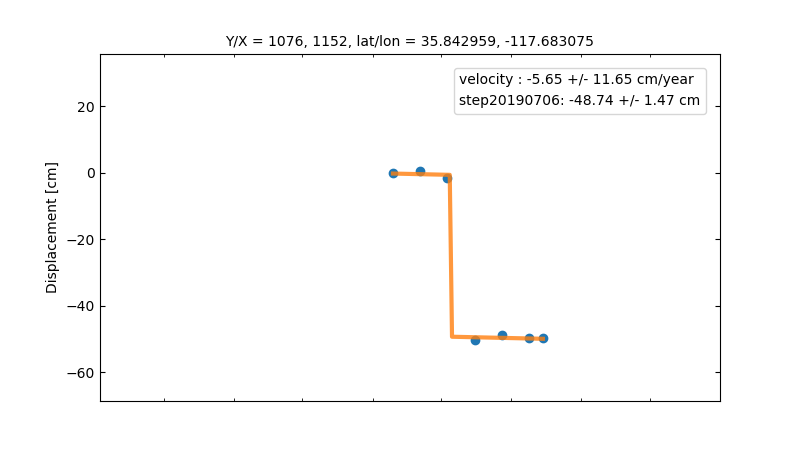

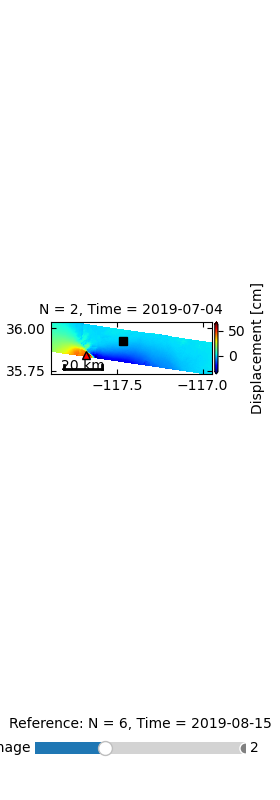

In [10]:
%matplotlib widget
from mintpy.cli import tsview

ts_file = os.path.expanduser('/mnt/CEPH_PROJECTS/ESA_ClouDInSAR/Case_studies/InSAR_timeseries/openeo/RidgeCrest/mintpy/timeseries.h5')
cmd = f'{ts_file} --lalo 35.843 -117.683 --zero-first --step-date 20190706 --mask no'
tsview.main(cmd.split())